In [79]:
import numpy as np
import pandas as pd
import astropy.units as u

from astropy.coordinates import cartesian_to_spherical, SkyCoord, Galactocentric
from numpy.polynomial import Polynomial as P

ModuleNotFoundError: No module named 'numpy.polyfit'

In [2]:
# import funcs

%run ./utils.ipynb

In [3]:
source = '/cosma5/data/durham/dc-pick2/simulations'

In [4]:
hyades_path = source + '/Hyades'
times = [400]

step, glob_df, Myr_per_Nbody = get_steps_at_times(hyades_path, times)
step_df = step[400]

/tmp/ipykernel_733365/2808405432.py:27: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  return pd.read_csv(glob_path, sep=r"\s+", index_col=False)


In [5]:
step_df

,M,NAM,POT,Vx,Vy,Vz,X,Y,Z
0,0.021790,264,-0.294557,-2.875108,-0.759959,0.132951,-468.954498,62.232044,25.689085
1,0.017319,2200,-0.297220,-3.231250,-1.230674,0.127831,-469.838287,61.196671,26.192299
2,0.273274,5497,-0.304513,-3.492539,-1.123590,-0.622551,-468.985504,62.202721,25.700405
3,0.275496,3166,-0.305071,-3.766843,-0.156436,-1.327741,-470.918610,60.395939,27.506559
4,0.037463,7150,-0.221297,-2.804093,-0.379673,-0.147797,-465.125275,57.330475,30.037407
...,...,...,...,...,...,...,...,...,...
8459,0.021318,3022,-0.027435,-4.882914,-0.526838,-2.412590,-568.897888,65.661263,-1.036683
8460,0.014233,5438,-0.024733,-5.136313,0.490726,-1.459774,-560.967712,-15.050610,6.628565
8461,0.025820,7098,-0.017927,-6.164476,0.606497,-2.129588,-580.239441,-47.458511,-17.405138
8462,0.086245,6579,-0.031329,-0.485701,-1.837952,-1.730998,-394.298676,100.627357,-10.159351


In [152]:
gc = SkyCoord(
    x=step_df["X"].values * u.pc,
    y=step_df["Y"].values * u.pc,
    z=step_df["Z"].values * u.pc,
    v_x=step_df["Vx"].values * (u.km/u.s),
    v_y=step_df["Vy"].values * (u.km/u.s),
    v_z=step_df["Vz"].values * (u.km/u.s),
    frame=Galactocentric()
)

icrs = gc.icrs
step_df["ra"] = icrs.ra.deg
step_df["dec"] = icrs.dec.deg
step_df["dist"] = icrs.distance.to(u.pc).value

In [153]:
step_df

,M,NAM,POT,Vx,Vy,Vz,X,Y,Z,R,LAT,LON,ra,dec,dist,x_deg,y_deg
0,0.021790,264,-0.294557,-2.875108,-0.759959,0.132951,-468.954498,62.232044,25.689085,473.762681,0.054250,3.009660,266.503211,-28.442953,7653.273451,0.017162,-0.004545
1,0.017319,2200,-0.297220,-3.231250,-1.230674,0.127831,-469.838287,61.196671,26.192299,474.530384,0.055224,3.012071,266.494992,-28.447564,7652.381680,0.009935,-0.009155
2,0.273274,5497,-0.304513,-3.492539,-1.123590,-0.622551,-468.985504,62.202721,25.700405,473.790135,0.054271,3.009730,266.503000,-28.443095,7653.242215,0.016977,-0.004687
3,0.275496,3166,-0.305071,-3.766843,-0.156436,-1.327741,-470.918610,60.395939,27.506559,475.571884,0.057871,3.014038,266.481918,-28.447504,7651.296069,-0.001561,-0.009094
4,0.037463,7150,-0.221297,-2.804093,-0.379673,-0.147797,-465.125275,57.330475,30.037407,469.606804,0.064007,3.018953,266.449780,-28.457541,7657.068291,-0.029815,-0.019135
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8459,0.021318,3022,-0.027435,-4.882914,-0.526838,-2.412590,-568.897888,65.661263,-1.036683,572.675548,-0.001810,3.026683,266.718827,-28.520540,7553.392444,0.206600,-0.082333
8460,0.014233,5438,-0.024733,-5.136313,0.490726,-1.459774,-560.967712,-15.050610,6.628565,561.208725,0.011812,3.168416,266.298749,-29.012980,7561.033914,-0.161743,-0.574695
8461,0.025820,7098,-0.017927,-6.164476,0.606497,-2.129588,-580.239441,-47.458511,-17.405138,582.437171,-0.029888,3.223202,266.330142,-29.318665,7541.980015,-0.133899,-0.880341
8462,0.086245,6579,-0.031329,-0.485701,-1.837952,-1.730998,-394.298676,100.627357,-10.159351,407.063291,-0.024960,2.891720,266.927044,-28.341540,7728.391842,0.390208,0.096151


In [154]:
centre_deg = SkyCoord(ra=np.median(step_df['ra']) * u.deg,
                  dec=np.median(step_df['dec']) * u.deg,
                  frame='icrs')

sky_deg = SkyCoord(ra=step_df['ra'].values * u.deg,
                   dec=step_df['dec'].values * u.deg,
                   frame='icrs')
                               
tp = sky_deg.transform_to(centre_deg.skyoffset_frame())

step_df["x_deg"] = tp.lon.deg
step_df["y_deg"] = tp.lat.deg

In [196]:
density_filter=20
bins=100

xmin, xmax = np.percentile(step_df["x_deg"], [.5,99.5])
ymin, ymax = np.percentile(step_df["y_deg"], [.5,99.5])

mass_grid, xedges, yedges = np.histogram2d(step_df["x_deg"], step_df["y_deg"]
                                           ,bins=bins,weights=step_df['M'],
                                          range=[[xmin, xmax], [ymin, ymax]])


dx = xedges[1] - xedges[0]
dy = yedges[1] - yedges[0]


density = mass_grid / (dx * dy)

mask = density > density_filter

masked_density = density.copy()
masked_density[~mask] = 0

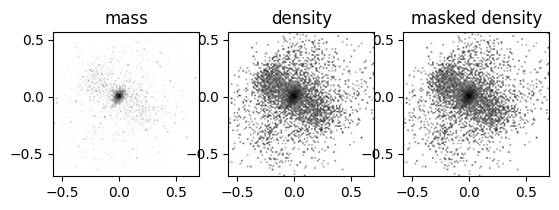

In [197]:
fig, ax = plt.subplots(1,3)
ax[0].imshow(
        np.log10(mass_grid.T + 1),
        origin='lower',
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        cmap='gray_r',
        interpolation='spline36'
    )
ax[0].set_title('mass')
ax[1].imshow(
        np.log10(density.T + 1),
        origin='lower',
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        cmap='gray_r',
        interpolation='spline36'
    )
ax[1].set_title('density')
ax[2].imshow(
        np.log10(masked_density.T + 1),
        origin='lower',
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        cmap='gray_r',
        interpolation='spline36'
    )
ax[2].set_title('masked density')

#ax.set_xlim([-offset,offset])
#ax.set_ylim([-offset,offset])

plt.show()

In [198]:
ridge_x = []
ridge_y = []
ridge_w = []

xc = (xedges[:-1] + xedges[1:]) / 2
yc = (yedges[:-1] + yedges[1:]) / 2

for i in range(density.shape[0]):
    col = density[i, :]

    j = np.argmax(col)

    if col[j] < density_filter:
        continue

    ridge_x.append(xc[i])
    ridge_y.append(yc[j])
    ridge_w.append(col[j])

ridge_x = np.array(ridge_x)
ridge_y = np.array(ridge_y)
ridge_w = np.array(ridge_w)


coeffs = np.polyfit(ridge_x, ridge_y, w=np.log(1+ridge_w), deg=4)
coeffs

array([ 0.64176027,  1.67704278, -0.78943611, -0.29225314,  0.0432358 ])

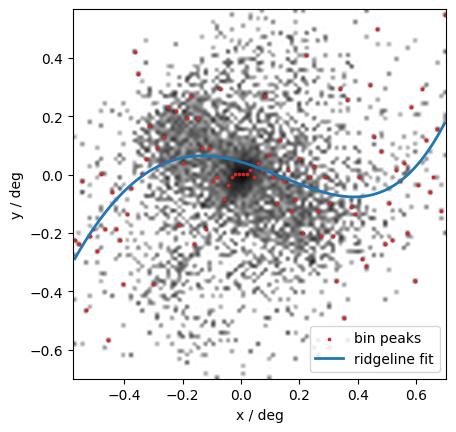

In [199]:
x_fit = np.linspace(ridge_x.min(), ridge_x.max(), 500)
y_fit = np.polyval(coeffs, x_fit)

fig, ax = plt.subplots()
ax.imshow(
        np.log10(masked_density.T + 1),
        origin='lower',
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        cmap='gray_r',
        interpolation='spline36'
    )
ax.scatter(ridge_x, ridge_y, s=3, label="bin peaks", color='tab:red')
ax.plot(x_fit, y_fit, color="tab:blue", linewidth=2, label="ridgeline fit")


ax.set_aspect("equal")
plt.legend()
ax.set_xlabel("x / deg")
ax.set_ylabel("y / deg")
plt.show()